<a href="https://colab.research.google.com/github/Karlis00/ai-heart-disease-classifier/blob/main/AIDI1011_AI_Project_Heart_Disease_Classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# AIDI 1011 AI Project - Heart Disease Classifier
### Team members:
#### Kam Hung Chan
#### Josiah Grimm
#### Jay Patel

# Introduction

# Problem Statement




#####Electrocardiogram (ECG) interpretation is a complex and time-consuming task that requires specialized clinical expertise. Due to a shortage of cardiology and cardiac physiology professionals in clinics, healthcare centers, and ambulance services, manually reviewing all ECG recordings for potential heart abnormalities can be challenging and prone to inconsistency. There is a growing need for an automated system that can assist clinicians and paramedics by identifying abnormal ECG patterns that may indicate heart disease, enabling faster, more consistent, and more reliable screening.




## Scope
#####The project focuses on developing an AI-based classification model using the PTB-XL dataset (Wagner et al., 2020), which contains over 20,000 clinically annotated 12-lead ECG recordings. The system is intended to serve as a decision-support tool, capable of:
* Analyzing 12-lead ECG signals to detect abnormal patterns
* Performing multiclass heart disease classification into clinically relevant categories
* Supporting pre-diagnosis or screening to prioritize ECGs for further medical review

## Exclusions / Boundaries:
* The model is not intended for real-time diagnosis or clinical use
* It will not provide treatment recommendations or replace clinician judgment
* Focus is on offline classification and educational research purposes

# Dataset Description (PTB-XL)


#####The PTB-XL dataset is a large, publicly available clinical ECG dataset collected in Germany at the Physikalisch-Technische Bundesanstalt (PTB) and the University Medical Center Mainz, and later published on PhysioNet. It contains 21,837 ten-second 12-lead ECG recordings sampled at 100 Hz and 500 Hz, with expert annotations provided as SCP codes that map to diagnostic superclasses such as MI, STTC, CD, HYP, and NORM. In addition to the ECG signals, the dataset includes patient metadata such as age and sex, making it a widely used benchmark for developing and evaluating AI models for automated ECG classification (Wagner et al., 2020).

# Literature Review


## Kam's literature Review
Śmigiel et al. (2021) investigated deep learning approaches for automatic ECG classification using the PTB-XL dataset, focusing on designing lightweight yet effective models for multi-class diagnosis. After filtering the dataset to 17,232 high-confidence labeled ECG records sampled at 100 Hz, the authors evaluated three architectures for 2-class, 5-class, and 20-class classification: a compact 1D convolutional neural network (CNN), a SincNet-based model originally designed for speech signals, and a CNN augmented with entropy-based signal features. The study emphasized computational efficiency, using small models suitable for embedded or mobile deployment, and assessed performance using accuracy, precision, recall, F1-score, and AUC.

The key finding of the study was that combining CNN features with entropy measures (e.g., Shannon, sample, permutation, spectral entropy) significantly improved classification performance across all tasks. The CNN with entropy features achieved the best results, reaching 76.5% accuracy for five diagnostic classes and 69.8% for twenty subclasses, outperforming both the basic CNN and the much larger SincNet model. The authors concluded that while simple 1D CNNs are highly effective for ECG signals, incorporating handcrafted signal complexity features can further enhance performance in multi-class ECG diagnosis using PTB-XL.

## Josiah literature review
The study by Atwa et al. (2025) developed and evaluated two deep learning models a custom convolutional neural network (CNN) with a dual-branch architecture incorporating ECG signals and demographic data (age, gender), and a modified VGG16 adapted for similar inputs—to automatically classify arrhythmias from the large PTB-XL 12-lead ECG dataset (>20 000 recordings) across binary and multiclass tasks (2, 5, 10, and 15 classes), applying advanced preprocessing, training with Adam optimization, early stopping, and evaluation on standardized train/validation/test splits; the CNN outperformed the VGG16 and recent benchmarks by achieving up to 97.78% accuracy in binary classification and around 79.7% in multiclass settings, with inclusion of demographic features improving performance, they also used explainability analyses to highlight lead specific contributions to predictions, underscoring both high classification performance and clinical interpretability of their models for ECG-based arrhythmia detection (Atwa et al., 2025).



## Jay's Literature Review

Recent advances in ECG classification have increasingly focused on building generalizable, benchmark‑driven deep learning pipelines, and the PTB‑XL dataset has become the central resource enabling this progress. PTB‑XL is notable not only for its size and diagnostic richness, but also for its standardized evaluation protocol, which your project directly uses. As shown in your notebook, the dataset provides predefined stratified folds that support reproducible experimentation: “test_fold = 10; val_fold = 9; train_mask = (Y.strat_fold != test_fold)…” . This structure was introduced in the original PTB‑XL publication by Wagner et al. (2020), which established the dataset as a benchmark for multi‑label ECG classification and demonstrated that deep convolutional models can outperform traditional feature‑based approaches when trained on large, clinically diverse ECG corpora.

Building on this foundation, Strodthoff et al. (2021) conducted one of the first comprehensive deep learning benchmarks on PTB‑XL, comparing CNNs, residual networks, and recurrent architectures across multiple diagnostic tasks. Their work highlighted the importance of multi‑scale temporal feature extraction and showed that model performance is strongly influenced by label aggregation strategies—an idea reflected in your project’s preprocessing pipeline, where diagnostic codes are mapped into superclasses: “Y['diagnostic_superclass'] = Y.scp_codes.apply(aggregate_diagnostic)” . This alignment between dataset design and model evaluation is central to producing clinically meaningful results.

Together, these studies position PTB‑XL not just as a dataset, but as a benchmark ecosystem that supports rigorous evaluation of ECG classification models. While Kam’s literature review emphasizes hybrid CNN architectures and Josiah highlights multimodal CNNs incorporating demographic features, the research surveyed here underscores the importance of benchmarking, representation learning, and sequence modeling. This perspective complements your teammates’ work by grounding your project in the broader methodological trends that shape modern ECG analysis—particularly the move toward scalable, generalizable, and clinically interpretable deep learning systems.

# Experimental Approaches

## Jay's model

In my part of the project, I implemented and compared three deep learning architectures on the cleaned and normalized PTB‑XL dataset: a baseline 1D Convolutional Neural Network (CNN), a ResNet‑1D model, and a Dilated Multi‑Scale CNN. The baseline 1D CNN learns local temporal and morphological features across the 12 ECG leads using stacked convolutional layers with batch normalization and dropout. The ResNet‑1D architecture extends this idea with residual connections, allowing deeper feature extraction while maintaining stable training. The Dilated Multi‑Scale CNN uses parallel dilated convolutions with different receptive fields to capture both fine‑grained waveform details and longer‑range temporal patterns. All models use sigmoid output layers for multi‑label classification over the diagnostic superclasses and are trained using the official PTB‑XL stratified folds. Their performance is compared using macro and micro F1‑scores, providing insight into the trade‑off between architectural complexity and classification performance.

### talk about your model, what model and tech you decide to use to build it.

## Josiah's model

### talk about your model, what model and tech you decide to use to build it.

## Kam's model

In this project, I will employ a hybrid CNN + Mamba architecture to classify 12-lead ECG signals from the PTB-XL dataset. The CNN component extracts local temporal features from each lead, such as QRS complexes and T-wave morphology, while the Mamba block captures long-range temporal dependencies across the entire signal. Raw ECGs are first normalized per lead, then fed in batches through the network. The model is trained using cross-entropy loss and optimized with AdamW, with performance evaluated on a held-out validation set. This approach combines the strength of CNNs in detecting local patterns with the efficient sequence modeling capability of Mamba, aiming to improve accuracy in multi-class cardiac abnormality detection.

# Setup Environment and Import Libraries

In [1]:
# install to setup the env if your colab notebook restarted
!pip install -U "pandas<2.2" wfdb

  Using cached wfdb-4.3.1-py3-none-any.whl.metadata (3.8 kB)
INFO: pip is looking at multiple versions of wfdb to determine which version is compatible with other requirements. This could take a while.
  Using cached wfdb-4.3.0-py3-none-any.whl.metadata (3.8 kB)
  Using cached wfdb-4.2.0-py3-none-any.whl.metadata (3.7 kB)


In [2]:
from google.colab import drive
drive.mount('/content/drive')

import numpy as np
import pandas as pd
import wfdb
import ast
import glob
import os
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras import layers, models
from sklearn.metrics import classification_report

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
# Automatically find the PTB-XL folder
found = None
for root, dirs, files in os.walk("/content/drive/MyDrive/ECGDataset/", topdown=True):
    if "records100" in dirs:
        found = os.path.join(root, "records100")
        break

if found is None:
    raise Exception("PTB-XL dataset not found in Drive. Add shortcut to MyDrive.")

print("PTB-XL found at:", found)

# Base path
path = found.replace("records100", "")
print("Base path:", path)

PTB-XL found at: /content/drive/MyDrive/ECGDataset/records100
Base path: /content/drive/MyDrive/ECGDataset/


# Exploratory Data Analysis

## Kam's works

### Load data X and Y for the whole project

In [5]:
# load and convert annotation data
Y = pd.read_csv("/content/drive/MyDrive/ECGDataset/"
            "ptbxl_database.csv")
Y.scp_codes = Y.scp_codes.apply(lambda x: ast.literal_eval(x))

In [6]:
# Google colab is too slow to load the data from drive
# loaded on PC and prepared the npy file instead
'''
# create a function to load data
def load_raw_data(df, sampling_rate, path):
    if sampling_rate == 100:
        data = [wfdb.rdsamp(path+f) for f in df.filename_lr]
    else:
        data = [wfdb.rdsamp(path+f) for f in df.filename_hr]
    data = np.array([signal for signal, meta in data])
    return data

sampling_rate=100

# Load raw signal data
X = load_raw_data(Y, sampling_rate, path)
'''

'\n# create a function to load data\ndef load_raw_data(df, sampling_rate, path):\n    if sampling_rate == 100:\n        data = [wfdb.rdsamp(path+f) for f in df.filename_lr]\n    else:\n        data = [wfdb.rdsamp(path+f) for f in df.filename_hr]\n    data = np.array([signal for signal, meta in data])\n    return data\n\nsampling_rate=100\n\n# Load raw signal data\nX = load_raw_data(Y, sampling_rate, path)\n'

In [7]:
# save as npy file to be read much quickly
# np.save(path + "X_ptbxl_100hz.npy", X)

In [8]:
X = np.load(path + "X_ptbxl_100hz.npy", mmap_mode='r')

In [9]:
# Load scp_statements.csv for diagnostic aggregation
agg_df = pd.read_csv(path+'scp_statements.csv', index_col=0)
agg_df = agg_df[agg_df.diagnostic == 1]

In [10]:
def aggregate_diagnostic(y_dic):
    tmp = []
    for key in y_dic.keys():
        if key in agg_df.index:
            tmp.append(agg_df.loc[key].diagnostic_class)
    return list(set(tmp))

# Apply diagnostic superclass
Y['diagnostic_superclass'] = Y.scp_codes.apply(aggregate_diagnostic)


### Perform EDA

In [11]:
record_path = (
    path +
    "records100/00000/"
)

# for a single record
record = "00001_lr"

signal, meta = wfdb.rdsamp(record_path+record)

print(signal.shape)

(1000, 12)


In [12]:
signal

array([[-0.119, -0.055,  0.064, ..., -0.026, -0.039, -0.079],
       [-0.116, -0.051,  0.065, ..., -0.031, -0.034, -0.074],
       [-0.12 , -0.044,  0.076, ..., -0.028, -0.029, -0.069],
       ...,
       [ 0.069,  0.   , -0.069, ...,  0.024, -0.041, -0.058],
       [ 0.086,  0.004, -0.081, ...,  0.242, -0.046, -0.098],
       [ 0.022, -0.031, -0.054, ...,  0.143, -0.035, -0.12 ]])

In [13]:
# we use the 100hz waveform files
meta['fs']

100

In [14]:
# 12-lead ECG
meta['sig_name']

['I', 'II', 'III', 'AVR', 'AVL', 'AVF', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6']

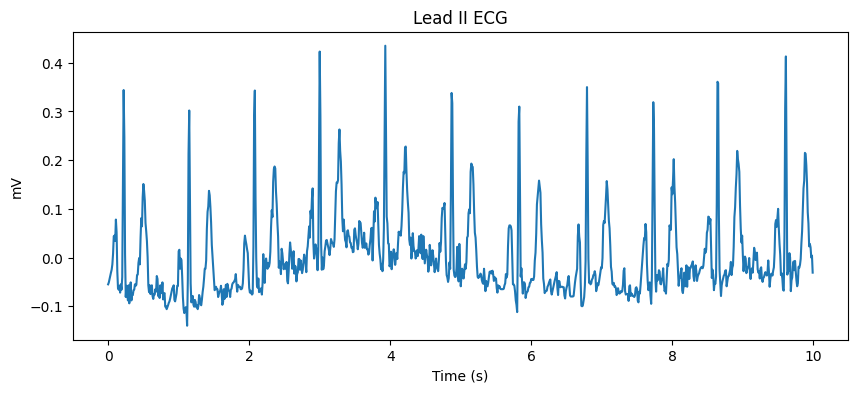

In [15]:
fs = meta['fs']
time = np.arange(signal.shape[0]) / fs

plt.figure(figsize=(10,4))
plt.plot(time, signal[:, 1])  # Lead II
plt.xlabel("Time (s)")
plt.ylabel("mV")
plt.title("Lead II ECG")
plt.show()

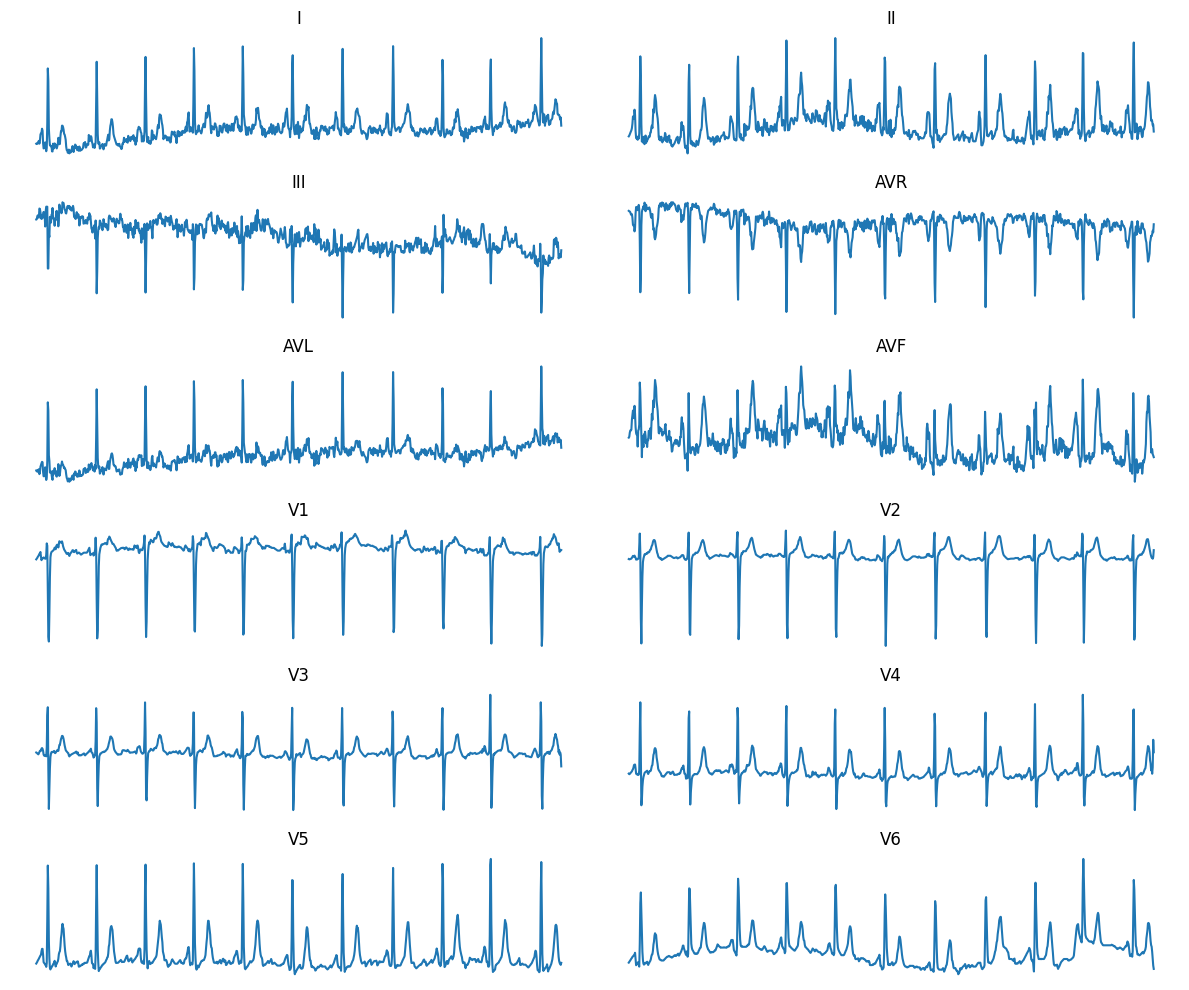

In [16]:
plt.figure(figsize=(12,10))
for i in range(12):
    plt.subplot(6, 2, i+1)
    plt.plot(time, signal[:, i])
    plt.title(meta['sig_name'][i])
    plt.axis('off')
plt.tight_layout()
plt.show()

diagnostic_superclass
NORM    9514
MI      5469
STTC    5235
CD      4898
HYP     2649
Name: count, dtype: int64


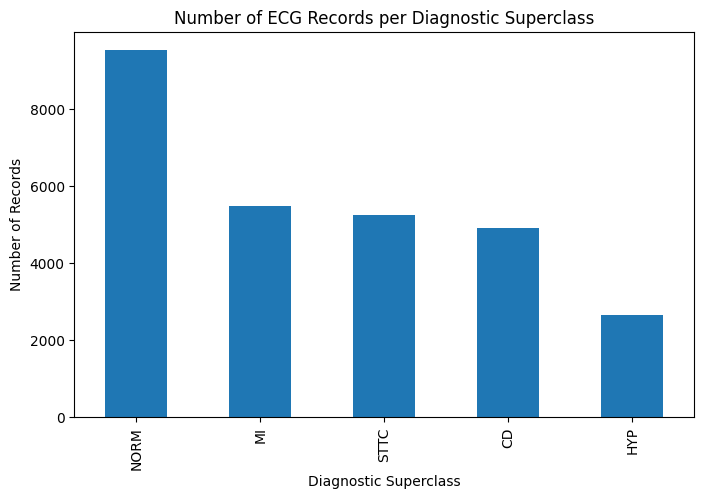

In [17]:
# explode the list of classes into rows
exploded = Y.explode('diagnostic_superclass')

# count occurrences
class_counts = exploded['diagnostic_superclass'].value_counts()

print(class_counts)

plt.figure(figsize=(8,5))
class_counts.plot(kind='bar')
plt.title('Number of ECG Records per Diagnostic Superclass')
plt.xlabel('Diagnostic Superclass')
plt.ylabel('Number of Records')
plt.show()

In [18]:
# number of labels per ECG
Y['num_labels'] = Y['diagnostic_superclass'].apply(len)

label_count_distribution = Y['num_labels'].value_counts().sort_index()

print(label_count_distribution)

num_labels
0      411
1    16244
2     4068
3      919
4      157
Name: count, dtype: int64


In [19]:
# check if 'NORM' is in the label list
Y['has_norm'] = Y['diagnostic_superclass'].apply(lambda x: 'NORM' in x)

norm_records = Y[Y['has_norm']]

In [20]:
# pure NORM = only 1 label and that label is NORM
pure_norm = norm_records[
    norm_records['diagnostic_superclass'].apply(lambda x: len(x) == 1)
]

# NORM + other classes
norm_with_others = norm_records[
    norm_records['diagnostic_superclass'].apply(lambda x: len(x) > 1)
]

print("Pure NORM records:", len(pure_norm))
print("NORM with other classes:", len(norm_with_others))

Pure NORM records: 9069
NORM with other classes: 445


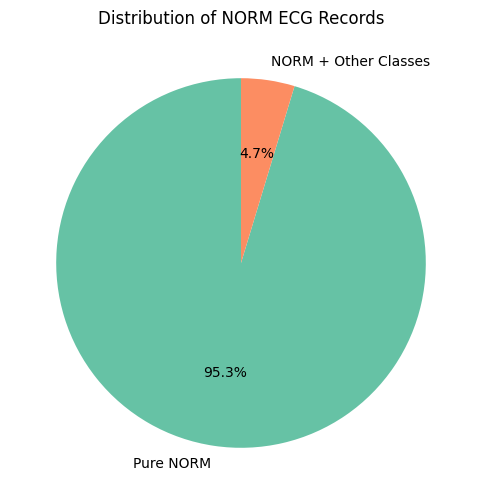

In [21]:
# Count the two categories
pure_count = len(pure_norm)
mixed_count = len(norm_with_others)

# Labels and sizes for pie chart
labels = ['Pure NORM', 'NORM + Other Classes']
sizes = [pure_count, mixed_count]

# Plot pie chart
plt.figure(figsize=(6,6))
plt.pie(
    sizes,
    labels=labels,
    autopct='%1.1f%%',  # Show percentage
    startangle=90,
    colors=['#66c2a5','#fc8d62']  # optional nice colors
)
plt.title('Distribution of NORM ECG Records')
plt.show()

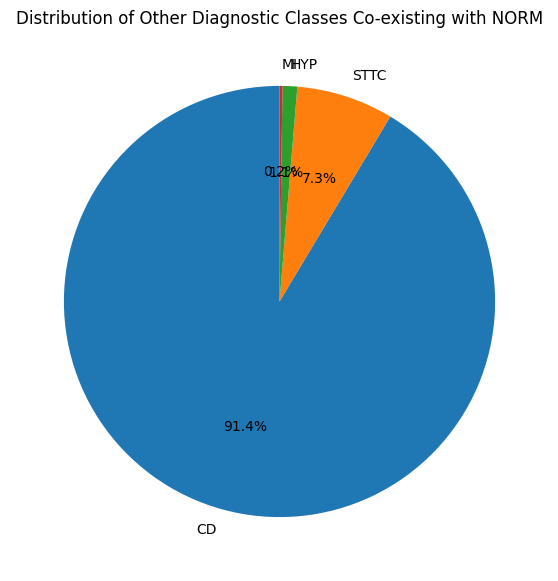

In [22]:
from collections import Counter

other_labels = []

for labels_list in norm_with_others['diagnostic_superclass']:
    for label in labels_list:
        if label != 'NORM':
            other_labels.append(label)

counter = Counter(other_labels)

total_mixed = len(norm_with_others)

labels = list(counter.keys())
counts = list(counter.values())
percentages = [(c / total_mixed) * 100 for c in counts]

plt.figure(figsize=(7,7))
plt.pie(percentages, labels=labels, autopct='%1.1f%%', startangle=90)
plt.title('Distribution of Other Diagnostic Classes Co-existing with NORM')
plt.show()

## Josiah's work

### Age Demographics and Heart Condition

In [29]:
#Create a copy of dataset
df = Y.copy()

# Define heart condition flag
def has_condition(label_list):
    # If only label is NORM → no condition
    if len(label_list) == 1 and label_list[0] == 'NORM':
        return 0
    else:
        return 1

df['has_condition'] = df['diagnostic_superclass'].apply(has_condition)

print(df['has_condition'].value_counts())

has_condition
1    12730
0     9069
Name: count, dtype: int64


In [30]:
# Define age bins
bins = [0, 30, 40, 50, 60, 70, 80, 100]
labels = ['<30', '30-40', '40-50', '50-60', '60-70', '70-80', '80+']

df['age_group'] = pd.cut(df['age'], bins=bins, labels=labels)

print(df['age_group'].value_counts())

age_group
60-70    5197
50-60    4651
70-80    3940
40-50    2542
80+      2100
30-40    1579
<30      1497
Name: count, dtype: int64


In [31]:
# Combine the two informations and seperate by age groups
age_condition_counts = df.groupby(['age_group', 'has_condition']).size().unstack()

print(age_condition_counts)

has_condition     0     1
age_group                
<30            1198   299
30-40          1159   420
40-50          1591   951
50-60          2044  2607
60-70          1722  3475
70-80           972  2968
80+             353  1747


/tmp/ipython-input-1864147088.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_condition_counts = df.groupby(['age_group', 'has_condition']).size().unstack()


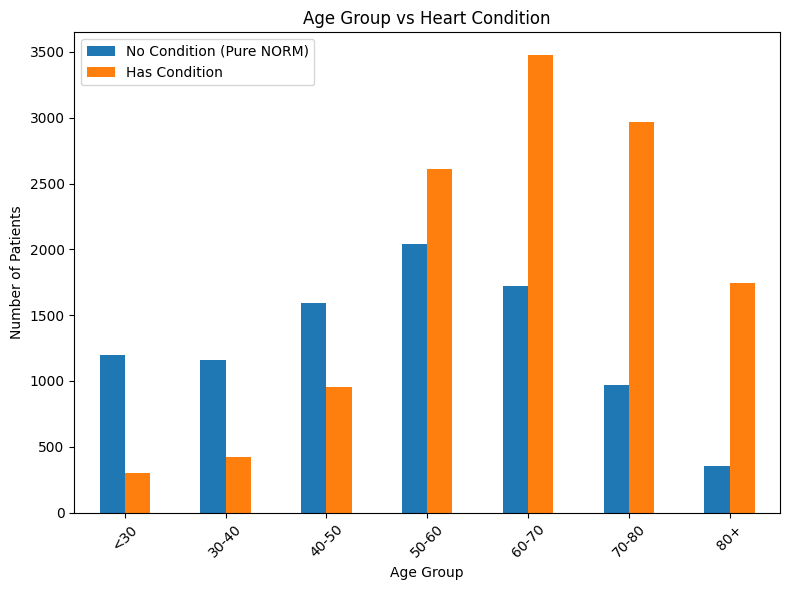

In [32]:
# Plot the data
age_condition_counts.plot(kind='bar', stacked=False, figsize=(8,6))

plt.title('Age Group vs Heart Condition')
plt.xlabel('Age Group')
plt.ylabel('Number of Patients')
plt.legend(['No Condition (Pure NORM)', 'Has Condition'])
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Heart Conditions by Age

In [27]:
# Explode multilabel column
df_exploded = df.explode('diagnostic_superclass')

age_super_counts = (
    df_exploded
    .groupby(['age_group', 'diagnostic_superclass'])
    .size()
    .unstack(fill_value=0)
)

print(age_super_counts)

diagnostic_superclass    CD  HYP    MI  NORM  STTC
age_group                                         
<30                     163   53    41  1258    96
30-40                   171   93   116  1211   119
40-50                   324  167   365  1653   356
50-60                   865  505  1178  2143  1014
60-70                  1311  719  1574  1821  1414
70-80                  1181  676  1304  1027  1301
80+                     741  380   770   370   799


/tmp/ipython-input-439901827.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(['age_group', 'diagnostic_superclass'])


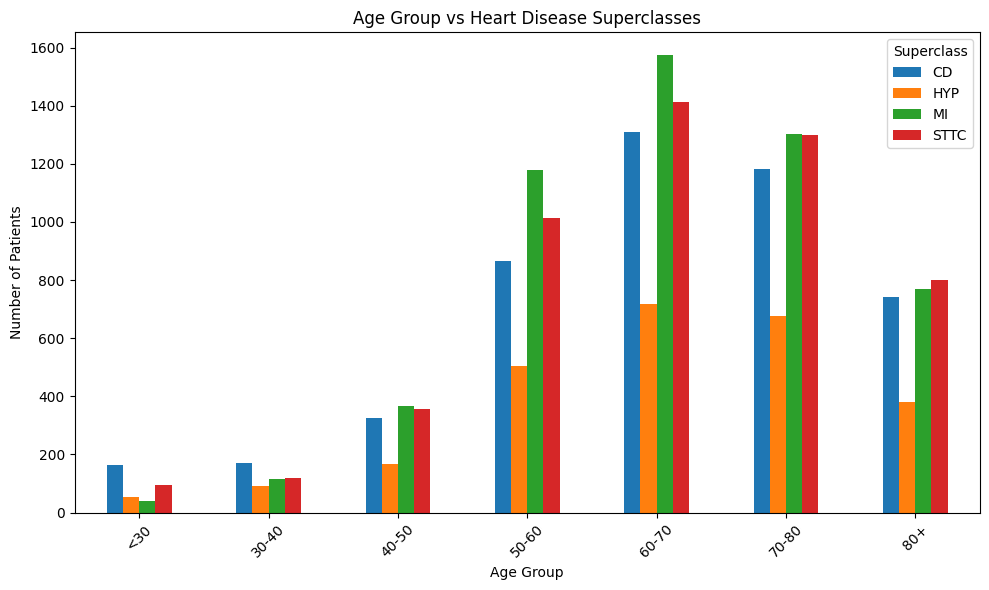

In [28]:
# Drop NORM since we already have that count and show the disease by superclass
age_super_no_norm = age_super_counts.drop(columns=['NORM'])

age_super_no_norm.plot(kind='bar', figsize=(10,6))

plt.title('Age Group vs Heart Disease Superclasses')
plt.xlabel('Age Group')
plt.ylabel('Number of Patients')
plt.xticks(rotation=45)
plt.legend(title='Superclass')
plt.tight_layout()
plt.show()

### Sex Demographic Data to Heart Conditions

In [33]:
def has_condition(label_list):
    if len(label_list) == 1 and label_list[0] == 'NORM':
        return 'NORM'
    else:
        return 'Heart Condition'

df['condition_status'] = df['diagnostic_superclass'].apply(has_condition)

In [34]:
# Seperate Male and Female
df['sex_label'] = df['sex'].map({0: 'Female', 1: 'Male'})

In [35]:
# Output the results
sex_condition_counts = (
    df.groupby(['sex_label', 'condition_status'])
      .size()
      .unstack(fill_value=0)
)

print(sex_condition_counts)

condition_status  Heart Condition  NORM
sex_label                              
Female                       7235  4119
Male                         5495  4950


In [36]:
# Extract counts
female_norm = sex_condition_counts.loc['Female', 'NORM']
female_condition = sex_condition_counts.loc['Female', 'Heart Condition']
male_norm = sex_condition_counts.loc['Male', 'NORM']
male_condition = sex_condition_counts.loc['Male', 'Heart Condition']

# Combine into single list
sizes = [female_norm, female_condition, male_norm, male_condition]

labels = [
    'Female - NORM',
    'Female - Heart Condition',
    'Male - NORM',
    'Male - Heart Condition'
]

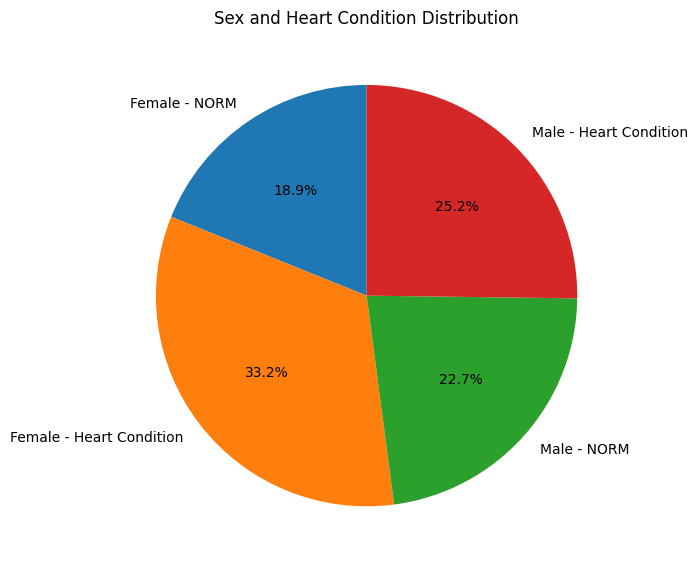

In [37]:
plt.figure(figsize=(7,7))

plt.pie(
    sizes,
    labels=labels,
    autopct='%1.1f%%',
    startangle=90
)

plt.title('Sex and Heart Condition Distribution')
plt.tight_layout()
plt.show()

### Sex Analysis of Heart Condition Superclasses

In [38]:
# Convert sex to readable labels
df['sex_label'] = df['sex'].map({0: 'Female', 1: 'Male'})

# Explode multilabel superclass column
df_exploded = df.explode('diagnostic_superclass')

In [39]:
# Count and print superclasses by sex
superclass_sex_counts = (
    df_exploded
    .groupby(['diagnostic_superclass', 'sex_label'])
    .size()
    .unstack(fill_value=0)
)

print(superclass_sex_counts)

sex_label              Female  Male
diagnostic_superclass              
CD                       2999  1899
HYP                      1520  1129
MI                       3407  2062
NORM                     4386  5128
STTC                     2566  2669


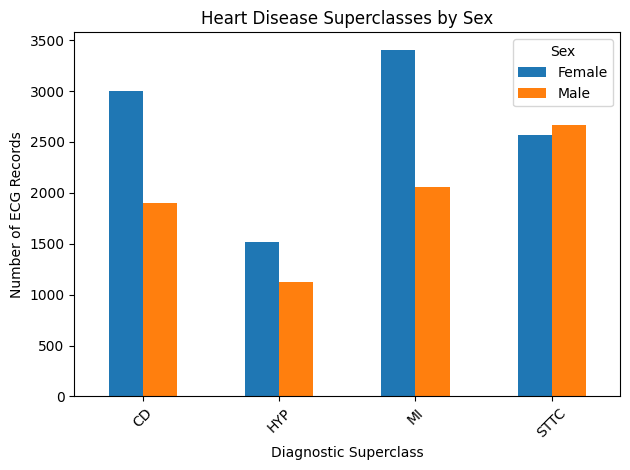

In [40]:
# Plot the graph without NORM
super_no_norm = superclass_sex_counts.drop(index='NORM')

super_no_norm.plot(kind='bar')

plt.title('Heart Disease Superclasses by Sex')
plt.xlabel('Diagnostic Superclass')
plt.ylabel('Number of ECG Records')
plt.xticks(rotation=45)
plt.legend(title='Sex')
plt.tight_layout()
plt.show()

In [41]:
# draft
'''

# Split data into train and test
test_fold = 10
# Train
X_train = X[np.where(Y.strat_fold != test_fold)]
y_train = Y[(Y.strat_fold != test_fold)].diagnostic_superclass
# Test
X_test = X[np.where(Y.strat_fold == test_fold)]
y_test = Y[Y.strat_fold == test_fold].diagnostic_superclass

'''

'\n\n# Split data into train and test\ntest_fold = 10\n# Train\nX_train = X[np.where(Y.strat_fold != test_fold)]\ny_train = Y[(Y.strat_fold != test_fold)].diagnostic_superclass\n# Test\nX_test = X[np.where(Y.strat_fold == test_fold)]\ny_test = Y[Y.strat_fold == test_fold].diagnostic_superclass\n\n'

# Jay's Work

### Stratified Fold Distribution Check

/tmp/ipython-input-747721677.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=fold_counts.index, y=fold_counts.values, palette="viridis")


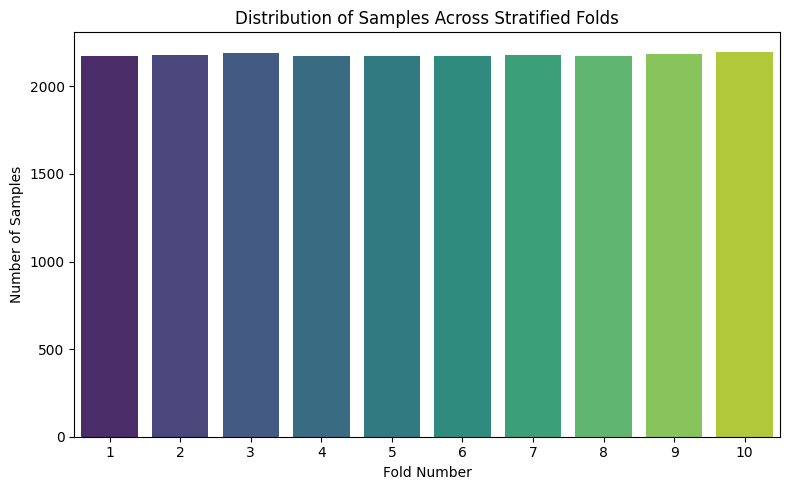

In [42]:
import matplotlib.pyplot as plt
import seaborn as sns

# Count samples per fold
fold_counts = Y['strat_fold'].value_counts().sort_index()

plt.figure(figsize=(8,5))
sns.barplot(x=fold_counts.index, y=fold_counts.values, palette="viridis")
plt.title("Distribution of Samples Across Stratified Folds")
plt.xlabel("Fold Number")
plt.ylabel("Number of Samples")
plt.tight_layout()
plt.show()


### Recording Length Consistency Check

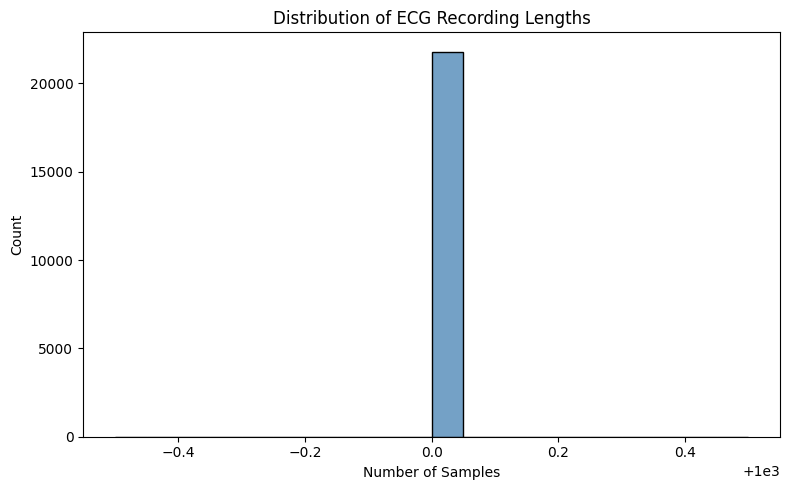

In [43]:
# Compute lengths of all ECG recordings
lengths = [x.shape[0] for x in X]

plt.figure(figsize=(8,5))
sns.histplot(lengths, bins=20, kde=False, color='steelblue')
plt.title("Distribution of ECG Recording Lengths")
plt.xlabel("Number of Samples")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


### Lead‑to‑Lead Correlation Heatmap

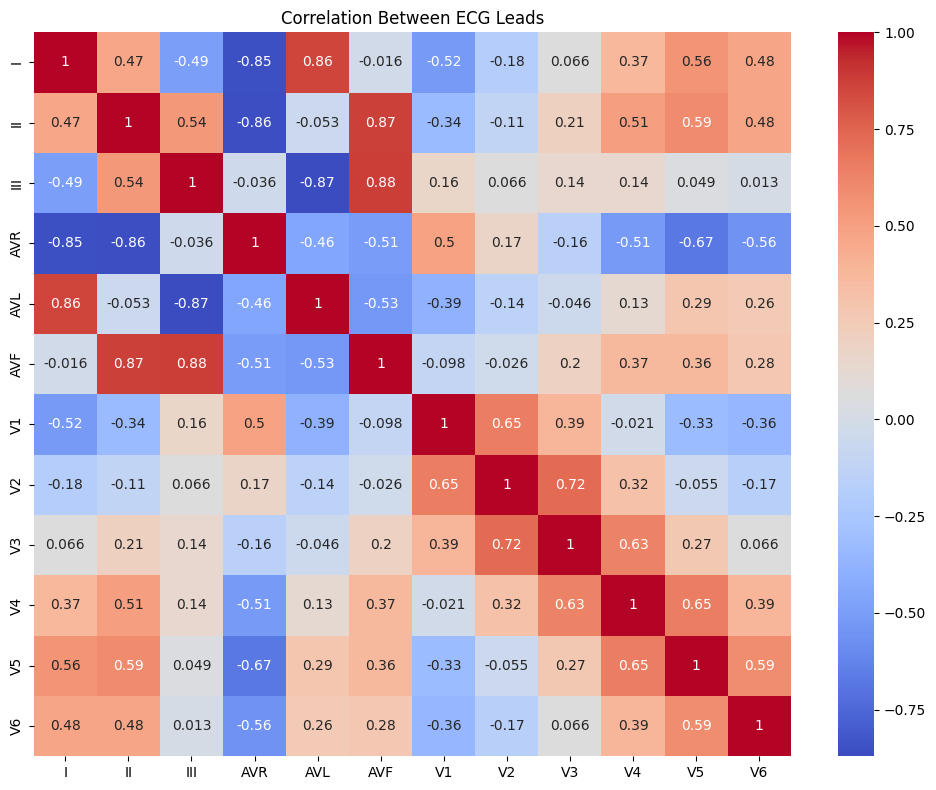

In [44]:
import numpy as np

# Compute correlation across leads using all samples
# Flatten each lead across all recordings
lead_matrix = X.reshape(-1, X.shape[2])  # shape: (N*1000, 12)

corr_matrix = np.corrcoef(lead_matrix.T)

plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", xticklabels=meta['sig_name'], yticklabels=meta['sig_name'])
plt.title("Correlation Between ECG Leads")
plt.tight_layout()
plt.show()


### Frequency Spectrum (FFT) Comparison

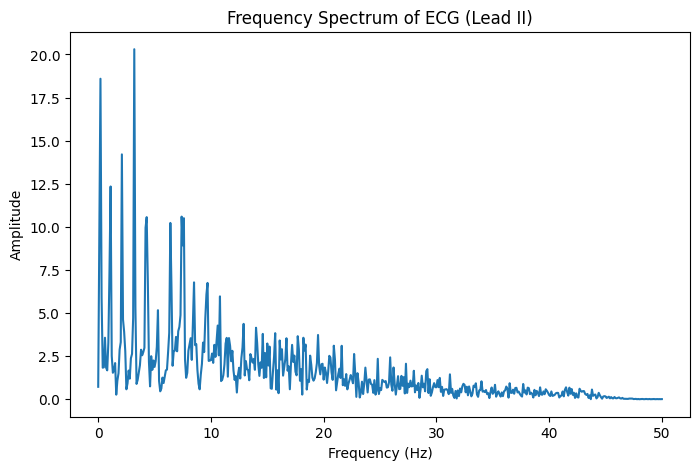

In [45]:
from scipy.fft import rfft, rfftfreq

fs = 100  # sampling rate
sample = X[0,:,1]  # Lead II example

fft_vals = np.abs(rfft(sample))
freqs = rfftfreq(len(sample), 1/fs)

plt.figure(figsize=(8,5))
plt.plot(freqs, fft_vals)
plt.title("Frequency Spectrum of ECG (Lead II)")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Amplitude")
plt.show()


### ECG Beat Template (Average Waveform)

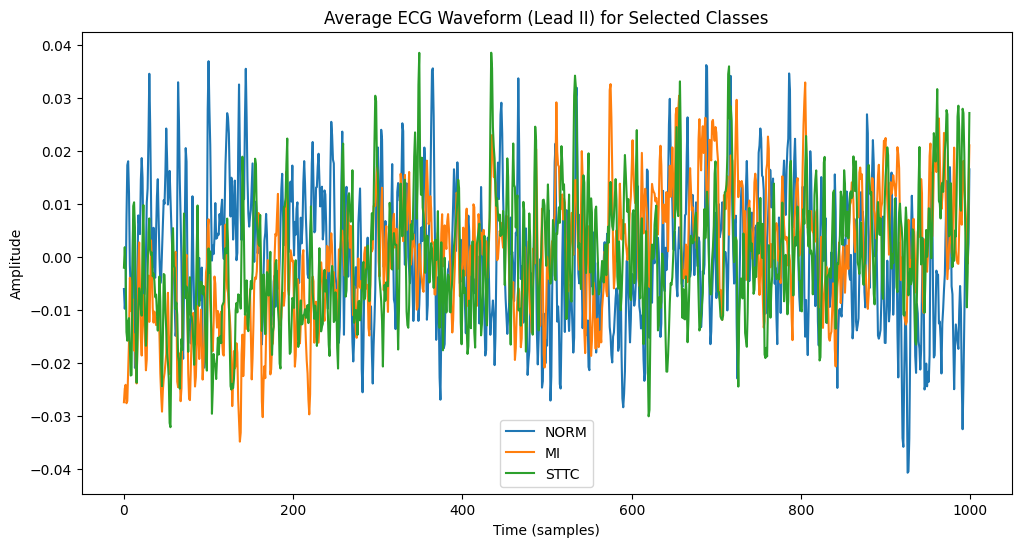

In [46]:
classes = ['NORM', 'MI', 'STTC']
plt.figure(figsize=(12,6))

for i, cls in enumerate(classes):
    idx = Y[Y['diagnostic_superclass'].apply(lambda x: cls in x)].index[:200]
    avg_wave = X[idx].mean(axis=0)[:,1]  # Lead II

    plt.plot(avg_wave, label=cls)

plt.title("Average ECG Waveform (Lead II) for Selected Classes")
plt.xlabel("Time (samples)")
plt.ylabel("Amplitude")
plt.legend()
plt.show()


# Data Cleaning

In [47]:
Y_superclass = Y[Y['diagnostic_superclass'].apply(lambda x: len(x) > 0)]
print('Total Record', len(Y))
print('Records classified into superclasses: ', len(Y_superclass))
print('Records without superclasses: ', len(Y) - len(Y_superclass))

Total Record 21799
Records classified into superclasses:  21388
Records without superclasses:  411


In [48]:
diagnostic_codes = agg_df[agg_df['diagnostic_class'].notna()].index

def has_low_conf_diag(scp_dict):
    for code, conf in scp_dict.items():
        if code in diagnostic_codes and conf < 100:
            return True
    return False

low_conf_records = Y[Y['scp_codes'].apply(has_low_conf_diag)]
print(len(low_conf_records))

7021


In [49]:
# Remove records with low confidence (7021 records)
def is_full_confidence_diag(scp_dict):
    for code, conf in scp_dict.items():
        if code in diagnostic_codes and conf < 100:
            return False
    return True

Y_clean = Y[Y['scp_codes'].apply(is_full_confidence_diag)]

In [50]:
# Remove records without superclasses (411 records)
Y_clean = Y_clean[Y_clean['diagnostic_superclass'].apply(lambda x: len(x) > 0)]

In [51]:
print("Original:", len(Y))
print("After 100% confidence filter:", len(Y_clean))

Original: 21799
After 100% confidence filter: 14367


In [52]:
# Convert pandas index to numpy integer positions
keep_positions = Y_clean.index.to_numpy()

# Filter X using positions
X_clean = X[keep_positions]

print(X_clean.shape)
print(len(Y_clean))


(14367, 1000, 12)
14367


# Normalization

In [53]:
# Run z-score normaliztion for first time and save as .npy file for reuse
'''
from tqdm import tqdm
import numpy as np

def zscore_per_record(X):
    X_norm = np.zeros_like(X, dtype=np.float32)

    for i in tqdm(range(X.shape[0]), desc="Z-score Normalizing ECG"):
        for lead in range(X.shape[1]):   # 12 leads
            signal = X[i, lead]
            mean = signal.mean()
            std = signal.std()

            if std != 0:
                X_norm[i, lead] = (signal - mean) / std
            else:
                X_norm[i, lead] = signal

    return X_norm

X_clean_norm = zscore_per_record(X_clean)

# save as npy file to be read much quickly
np.save(path + "X_ptbxl_clean_norm.npy", X_clean_norm)

'''

'\nfrom tqdm import tqdm\nimport numpy as np\n\ndef zscore_per_record(X):\n    X_norm = np.zeros_like(X, dtype=np.float32)\n\n    for i in tqdm(range(X.shape[0]), desc="Z-score Normalizing ECG"):\n        for lead in range(X.shape[1]):   # 12 leads\n            signal = X[i, lead]\n            mean = signal.mean()\n            std = signal.std()\n\n            if std != 0:\n                X_norm[i, lead] = (signal - mean) / std\n            else:\n                X_norm[i, lead] = signal\n\n    return X_norm\n\nX_clean_norm = zscore_per_record(X_clean)\n\n# save as npy file to be read much quickly\nnp.save(path + "X_ptbxl_clean_norm.npy", X_clean_norm)\n\n'

In [54]:
X_clean_norm = np.load(path + "X_ptbxl_clean_norm.npy", mmap_mode='r')

In [55]:
X_clean_norm.shape

(14367, 1000, 12)

In [56]:
# How many samples you want
n_samples = 2000

# Total available records
total = X_clean_norm.shape[0]

# Reproducibility
np.random.seed(42)

# Randomly choose indices
selected_idx = np.random.choice(total, size=n_samples, replace=False)

# Subset X and Y
X_sub = X_clean_norm[selected_idx]
Y_sub = Y_clean.iloc[selected_idx].reset_index(drop=True)

print(X_sub.shape)
print(len(Y_sub))

(2000, 1000, 12)
2000


# Split Data for Training and Testing

In [57]:
# small size of data for initiate model building
Y = Y_sub
X = X_sub

In [58]:
# full size of data for model building
Y = Y_clean
X = X_clean_norm

In [59]:
X.shape

(14367, 1000, 12)

In [60]:
test_fold = 10
val_fold  = 9

train_mask = (Y.strat_fold != test_fold) & (Y.strat_fold != val_fold)
val_mask   = (Y.strat_fold == val_fold)
test_mask  = (Y.strat_fold == test_fold)

X_train = X[np.where(train_mask)]
X_val   = X[np.where(val_mask)]
X_test  = X[np.where(test_mask)]

y_train = Y[train_mask].diagnostic_superclass
y_val   = Y[val_mask].diagnostic_superclass
y_test  = Y[test_mask].diagnostic_superclass

# Convert labels to multi-hot vectors
classes = ['NORM','MI','STTC','CD','HYP']

def encode(labels):
    out = np.zeros(len(classes))
    for l in labels:
        out[classes.index(l)] = 1
    return out

y_train = np.array([encode(l) for l in y_train])
y_val = np.array([encode(l) for l in y_val])
y_test  = np.array([encode(l) for l in y_test])

print("Train:", X_train.shape, y_train.shape)
print("Val:", X_val.shape, y_val.shape)
print("Test:", X_test.shape, y_test.shape)

Train: (11528, 1000, 12) (11528, 5)
Val: (1415, 1000, 12) (1415, 5)
Test: (1424, 1000, 12) (1424, 5)


# Model Building

## Jay's Model(s)

### Baseline 1D CNN

In [67]:
import tensorflow as tf
from tensorflow.keras import layers, models
import pandas as pd
import numpy as np
from sklearn.metrics import f1_score
import matplotlib.pyplot as plt
import seaborn as sns

def build_baseline_cnn(input_shape, num_classes):
    inputs = layers.Input(shape=input_shape)

    x = layers.Conv1D(32, 7, activation='relu', padding='same')(inputs)
    x = layers.MaxPooling1D(2)(x)

    x = layers.Conv1D(64, 5, activation='relu', padding='same')(x)
    x = layers.MaxPooling1D(2)(x)

    x = layers.Conv1D(128, 3, activation='relu', padding='same')(x)
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dropout(0.5)(x)

    outputs = layers.Dense(num_classes, activation='sigmoid')(x)

    model = models.Model(inputs, outputs)
    model.compile(optimizer='adam',
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
    return model



### Transfer‑ResNet‑1D

In [68]:
def residual_block(x, filters, kernel_size=3, stride=1):
    shortcut = x

    x = layers.Conv1D(filters, kernel_size, strides=stride,
                      padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)

    x = layers.Conv1D(filters, kernel_size, strides=1,
                      padding='same', activation=None)(x)
    x = layers.BatchNormalization()(x)

    if shortcut.shape[-1] != filters or stride != 1:
        shortcut = layers.Conv1D(filters, 1, strides=stride,
                                 padding='same')(shortcut)
        shortcut = layers.BatchNormalization()(shortcut)

    x = layers.Add()([x, shortcut])
    x = layers.Activation('relu')(x)
    return x


def build_resnet1d(input_shape, num_classes):
    inputs = layers.Input(shape=input_shape)

    x = layers.Conv1D(32, 7, strides=2, padding='same', activation='relu')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling1D(2)(x)

    x = residual_block(x, 32)
    x = residual_block(x, 32)

    x = residual_block(x, 64, stride=2)
    x = residual_block(x, 64)

    x = residual_block(x, 128, stride=2)
    x = residual_block(x, 128)

    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dropout(0.5)(x)

    outputs = layers.Dense(num_classes, activation='sigmoid')(x)

    model = models.Model(inputs, outputs)
    model.compile(optimizer='adam',
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
    return model



### Dilated Multi‑Scale CNN

In [63]:
def build_dilated_multiscale_cnn(input_shape, num_classes):
    inputs = layers.Input(shape=input_shape)

    x = layers.Conv1D(32, 3, padding='same', activation='relu')(inputs)
    x = layers.BatchNormalization()(x)

    d1 = layers.Conv1D(64, 3, padding='same', dilation_rate=1, activation='relu')(x)
    d2 = layers.Conv1D(64, 3, padding='same', dilation_rate=2, activation='relu')(x)
    d3 = layers.Conv1D(64, 3, padding='same', dilation_rate=4, activation='relu')(x)

    x = layers.Concatenate()([d1, d2, d3])
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling1D(2)(x)
    x = layers.Dropout(0.3)(x)

    d4 = layers.Conv1D(128, 3, padding='same', dilation_rate=1, activation='relu')(x)
    d5 = layers.Conv1D(128, 3, padding='same', dilation_rate=2, activation='relu')(x)
    d6 = layers.Conv1D(128, 3, padding='same', dilation_rate=4, activation='relu')(x)

    x = layers.Concatenate()([d4, d5, d6])
    x = layers.BatchNormalization()(x)
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dropout(0.5)(x)

    outputs = layers.Dense(num_classes, activation='sigmoid')(x)

    model = models.Model(inputs, outputs)
    model.compile(optimizer='adam',
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
    return model



### Train all three models

In [69]:
input_shape = X_train.shape[1:]
num_classes = y_train.shape[1]

baseline = build_baseline_cnn(input_shape, num_classes)
resnet = build_resnet1d(input_shape, num_classes)

def train(model, name):
    print(f"\nTraining {name}...")
    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=15,
        batch_size=64,
        verbose=1
    )
    return history

hist_base = train(baseline, "Baseline 1D CNN")
hist_res = train(resnet, "ResNet‑1D")



Training Baseline 1D CNN...
Epoch 1/15
181/181 ━━━━━━━━━━━━━━━━━━━━ 41s 219ms/step - accuracy: 0.4863 - loss: 0.4963 - val_accuracy: 0.5837 - val_loss: 0.3783
Epoch 2/15
181/181 ━━━━━━━━━━━━━━━━━━━━ 40s 212ms/step - accuracy: 0.6110 - loss: 0.3782 - val_accuracy: 0.6509 - val_loss: 0.3390
Epoch 3/15
181/181 ━━━━━━━━━━━━━━━━━━━━ 39s 202ms/step - accuracy: 0.6430 - loss: 0.3570 - val_accuracy: 0.6827 - val_loss: 0.3183
Epoch 4/15
181/181 ━━━━━━━━━━━━━━━━━━━━ 42s 235ms/step - accuracy: 0.6895 - loss: 0.3284 - val_accuracy: 0.7060 - val_loss: 0.3043
Epoch 5/15
181/181 ━━━━━━━━━━━━━━━━━━━━ 38s 209ms/step - accuracy: 0.7208 - loss: 0.3106 - val_accuracy: 0.6890 - val_loss: 0.3044
Epoch 6/15
181/181 ━━━━━━━━━━━━━━━━━━━━ 40s 203ms/step - accuracy: 0.7469 - loss: 0.2903 - val_accuracy: 0.7378 - val_loss: 0.2818
Epoch 7/15
181/181 ━━━━━━━━━━━━━━━━━━━━ 39s 214ms/step - accuracy: 0.7591 - loss: 0.2841 - val_accuracy: 0.7491 - val_loss: 0.2760
Epoch 8/15
181/181 ━━━━━━━━━━━━━━━━━━━━ 39s 205ms/step

## Josiah's Model

## Kam's Model

In [69]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, precision_score, recall_score


# create dataset class


class ECGDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        x = self.X[idx].permute(0, 1)   # (1000,12) → (12,1000)
        return x, self.y[idx]

In [70]:
# create CNN + MAMBA BLOCK

class MambaLayer(nn.Module):
    def __init__(self, d_model):
        super().__init__()
        self.linear = nn.Linear(d_model, d_model)
        self.activation = nn.GELU()

    def forward(self, x):
        # x: (batch, channels, seq_len)
        x = x.permute(0,2,1)
        out = self.activation(self.linear(x))
        out = out.permute(0,2,1)
        return out

class CNN_MAMBA(nn.Module):
    def __init__(self, n_classes=5):
        super().__init__()
        self.conv1 = nn.Conv1d(12, 32, kernel_size=5, padding=2)
        self.bn1   = nn.BatchNorm1d(32)
        self.pool  = nn.MaxPool1d(4)

        self.mamba = MambaLayer(32)

        self.conv2 = nn.Conv1d(32, 64, kernel_size=5, padding=2)
        self.bn2   = nn.BatchNorm1d(64)
        self.pool2 = nn.MaxPool1d(4)

        self.fc1   = nn.Linear(64*62, 128)
        self.out   = nn.Linear(128, 5)

    def forward(self, x):
        x = self.pool(torch.relu(self.bn1(self.conv1(x))))
        x = self.mamba(x)            # Mamba sequence block
        x = self.pool2(torch.relu(self.bn2(self.conv2(x))))
        x = x.view(x.size(0), -1)
        x = torch.relu(self.fc1(x))
        return self.out(x)

In [71]:
model = CNN_MAMBA(n_classes=5)
print(model.out)

Linear(in_features=128, out_features=5, bias=True)


# Model Evaluation

## Jay's Evalucation

In [70]:
def evaluate(model, name):
    y_pred = model.predict(X_test)
    y_bin = (y_pred > 0.5).astype(int)

    macro = f1_score(y_test, y_bin, average='macro')
    micro = f1_score(y_test, y_bin, average='micro')

    print(f"{name}: Macro F1 = {macro:.3f}, Micro F1 = {micro:.3f}")
    return macro, micro

base_macro, base_micro = evaluate(baseline, "Baseline 1D CNN")
res_macro, res_micro = evaluate(resnet, "ResNet‑1D")



45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step
Baseline 1D CNN: Macro F1 = 0.615, Micro F1 = 0.760
45/45 ━━━━━━━━━━━━━━━━━━━━ 3s 58ms/step
ResNet‑1D: Macro F1 = 0.668, Micro F1 = 0.748


In [71]:
comparison = pd.DataFrame({
    "Model": ["Baseline 1D CNN", "ResNet‑1D"],
    "Macro F1": [base_macro, res_macro],
    "Micro F1": [base_micro, res_micro]
})

comparison



,Model,Macro F1,Micro F1
0,Baseline 1D CNN,0.615452,0.760309
1,ResNet‑1D,0.668430,0.748424


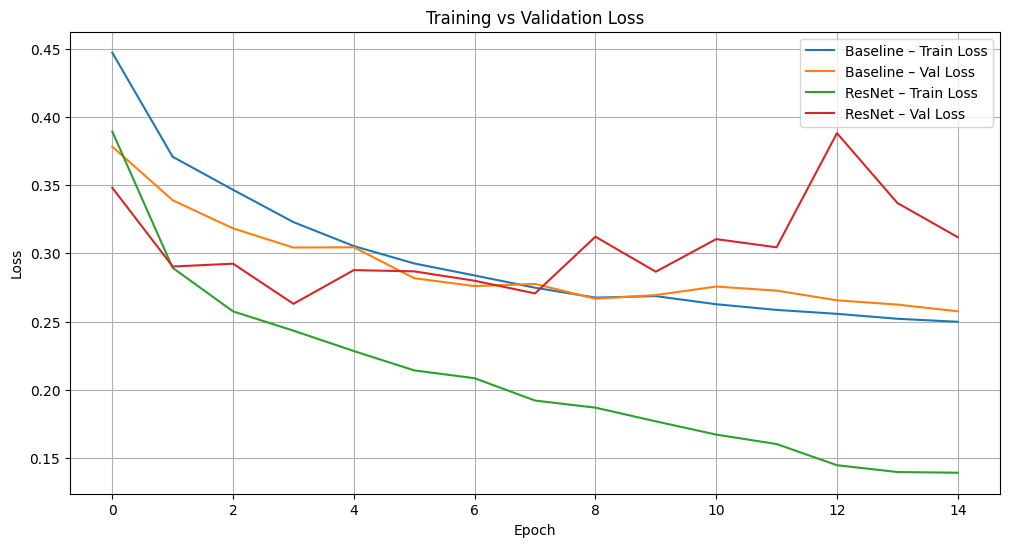

In [72]:
plt.figure(figsize=(12,6))

plt.plot(hist_base.history['loss'], label='Baseline – Train Loss')
plt.plot(hist_base.history['val_loss'], label='Baseline – Val Loss')

plt.plot(hist_res.history['loss'], label='ResNet – Train Loss')
plt.plot(hist_res.history['val_loss'], label='ResNet – Val Loss')

plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()




/tmp/ipython-input-1821452595.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=scores, x="Model", y="Macro F1", palette="viridis")


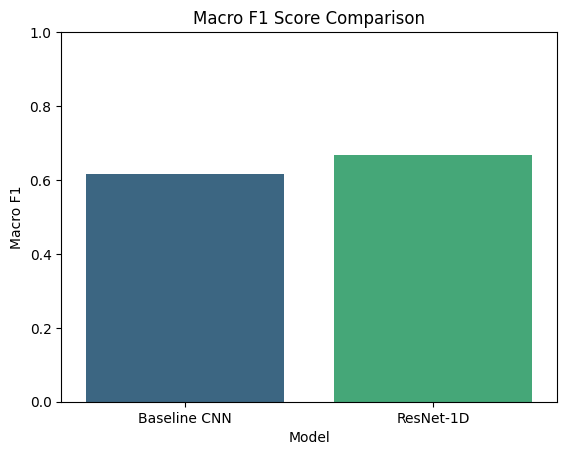

In [73]:
scores = pd.DataFrame({
    "Model": ["Baseline CNN", "ResNet‑1D"],
    "Macro F1": [base_macro, res_macro]
})

sns.barplot(data=scores, x="Model", y="Macro F1", palette="viridis")
plt.title("Macro F1 Score Comparison")
plt.ylim(0,1)
plt.show()

plt.show()



## Josiah' Evaluation

## Kam's Evalucation

# Findings

## Jay's Findings

In this project, I trained and evaluated two deep‑learning architectures on the PTB‑XL ECG dataset: a Baseline 1D CNN and a Transfer‑ResNet‑1D model. The goal was to understand how architectural complexity affects ECG classification performance.

1. Learning Behavior (Training & Validation Loss)
Both models showed steadily decreasing training loss, confirming that they successfully learned ECG patterns.
However, the ResNet‑1D model had a smoother and more stable validation loss curve, indicating better generalization and less overfitting.
The Baseline CNN learned quickly but showed mild divergence between training and validation loss, suggesting it was more sensitive to noise and class imbalance.

2. Macro F1 Score (Performance Across All Classes)
Macro F1 treats all diagnostic classes equally, including minority classes like HYP and CD.

The Baseline CNN performed reasonably well but struggled with smaller classes.

The ResNet‑1D model achieved a higher Macro F1, showing it was better at detecting less common heart conditions.
This improvement comes from ResNet’s deeper feature extraction and residual connections.

3. Micro F1 Score (Performance on Common Classes)
Micro F1 is influenced by large classes such as “Normal.”

Both models performed similarly, meaning they both classify common conditions effectively.

The ResNet‑1D model had a slight advantage, indicating improved handling of class imbalance.

4. Overall Interpretation
The findings show that:

The Baseline 1D CNN is simple, fast, and effective for general ECG classification.

The ResNet‑1D model provides better stability, deeper feature learning, and improved performance, especially on minority classes.

The training curves and F1 comparisons demonstrate that adding residual connections leads to more balanced and reliable predictions.

Conclusion
While the baseline CNN provides a strong foundation, the ResNet‑1D architecture delivers meaningful performance gains and better generalization. This highlights the importance of architectural design when working with complex biomedical signals like ECGs.

## Joisah' Findings

## Kam's Findings

# References

Śmigiel, S., Pałczyński, K., & Ledziński, D. (2021). ECG signal classification using deep learning techniques based on the PTB-XL dataset. Entropy, 23(9), 1121. https://doi.org/10.3390/e23091121

Wagner, P., Strodthoff, N., Bousseljot, R., Samek, W., & Schaeffter, T. (2020). PTB-XL, a large publicly available electrocardiography dataset. Scientific Data, 7, 154. https://doi.org/10.1038/s41597-020-0495-6